In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import os
import glob

import sys
sys.path.insert(1, './src')

### Load Diffusion pipeline

In [2]:
from utils_maps import *

exp_id = "2024-07-25_14-27-03_MLBriefs24_2_conditional_vanilla_downsample_mask"
exp_id = "2024-07-24_22-37-54_MLBriefs24_1_conditional_vanilla_encode_mask"
exp_id = "2024-08-02_14-35-03_MLBriefs24_5_conditional_CA_encodedmask"
model_path = f"/media/share/Datasets/diffusers_out/{exp_id}"

pipeline = load_pipeline(model_path)

Loading Diffusion pipeline from:
    - /media/share/Datasets/diffusers_out/2024-08-02_14-35-03_MLBriefs24_5_conditional_CA_encodedmask

VQ-VAE loaded
U-Net model loaded
Diffusion pipeline is ready



/home/ubuntu/anaconda3/envs/diffusion/lib/python3.9/site-packages/diffusers/configuration_utils.py:244: FutureWarning: It is deprecated to pass a pretrained model name or path to `from_config`.If you were trying to load a scheduler, please use <class 'diffusers.schedulers.scheduling_ddpm.DDPMScheduler'>.from_pretrained(...) instead. Otherwise, please make sure to pass a configuration dictionary instead. This functionality will be removed in v1.0.0.
  deprecate("config-passed-as-path", "1.0.0", deprecation_message, standard_warn=False)


### Generate N images

In [6]:
from PIL import Image
from tqdm import tqdm
import json
from datasets import load_dataset
from utils_maps import *

def save_pipeline_output_to_disk(output, batch_idx, batch_size, out_dir):
    images, cond_images = output
    os.makedirs(out_dir + "/ims", exist_ok=True)
    os.makedirs(out_dir + "/cond_ims", exist_ok=True)
    for idx in range(min(batch_size, images.shape[0])):
        local_d = {}
        global_img_idx = batch_idx * batch_size + idx
        img = Image.fromarray((images[idx]*255).astype(np.uint8))
        img.save(out_dir + f"/ims/{global_img_idx:05d}.png")
        if cond_images is not None:
            #cond_images[idx] = (cond_images[idx] * 0.5) + 0.5
            img = Image.fromarray((cond_images[idx]*255).astype(np.uint8))
            img.save(out_dir + f"/cond_ims/{global_img_idx:05d}.png")

def generate_N_images(pipeline, out_dir, n_images, batch_size=16, inference_steps=None, val_dataset=None):
    pipeline.nodule_attributes = True
    generator = torch.Generator(device=pipeline.device).manual_seed(0)
    if inference_steps is None:
        inference_steps = pipeline.scheduler.config.num_train_timesteps

    im_size = pipeline.vae.sample_size
    for batch_idx in tqdm(range(n_images//batch_size)):
        # prepare condition images
        if val_dataset is not None:
            sample_indices = np.arange(batch_idx*batch_size, (batch_idx+1)*batch_size)
            len_val = len(val_dataset)
            sample_indices[sample_indices >= len_val] = sample_indices[sample_indices >= len_val] % len_val
            input_condition_imgs = [val_dataset[int(i)]["condition"] for i in sample_indices]
            input_condition_imgs = torch.stack(input_condition_imgs)
        else:
            input_condition_imgs = None
        # run pipeline in inference (sample random noise and denoise)
        output = pipeline(
            input_condition_imgs=None if pipeline.args.unconditional else input_condition_imgs,
            generator=generator,
            batch_size=batch_size,
            num_inference_steps=inference_steps,
            output_type="numpy",
            return_dict=False
        )
        # save output images
        save_pipeline_output_to_disk(output, batch_idx, batch_size, out_dir)

    if n_images%batch_size > 0:
        batch_idx = n_images//batch_size
        batch_idx = batch_idx + 1 if batch_idx > 0 else 0
        # prepare condition images
        if val_dataset is not None:
            sample_indices = np.arange(batch_idx*batch_size, (batch_idx+1)*batch_size)
            len_val = len(val_dataset)
            sample_indices[sample_indices >= len_val] = sample_indices[sample_indices >= len_val] % len_val
            input_condition_imgs = [val_dataset[int(i)]["condition"] for i in sample_indices]
            input_condition_imgs = torch.stack(input_condition_imgs)
            input_condition_imgs = input_condition_imgs[:n_images%batch_size]
        else:
            input_condition_imgs = None
        # run pipeline in inference (sample random noise and denoise)
        output = pipeline(
            input_condition_imgs=None if pipeline.args.unconditional else input_condition_imgs,
            generator=generator,
            batch_size=n_images%batch_size,
            num_inference_steps=inference_steps,
            output_type="numpy",
            return_dict=False
        )
        # save output images
        save_pipeline_output_to_disk(output, batch_idx, batch_size, out_dir)


out_dir = model_path + "/fid_synthetic_5steps"
n_images = 16 #2048
bsz = 16

val_dataset = load_dataset(pipeline.args.val_dataset_name,
    pipeline.args.dataset_config_name,
    cache_dir=pipeline.args.cache_dir,
    split="train",
    )
val_dataset.set_transform(parse_maps_val)

generate_N_images(pipeline, out_dir, n_images, batch_size=bsz, inference_steps=5, val_dataset=val_dataset)


print("DONE")

Resolving data files:   0%|          | 0/1098 [00:00<?, ?it/s]

/tmp/ipykernel_1044003/3892726127.py:24: FutureWarning: Accessing config attribute `sample_size` directly via 'VQModel' object attribute is deprecated. Please access 'sample_size' over 'VQModel's config object instead, e.g. 'unet.config.sample_size'.
  im_size = pipeline.vae.sample_size
  0%|                                                                                                                                                                                        | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:05<00:00,  5.18s/it]

DONE


### Per-class evaluation starts here

- Prepare simplified segmentation masks (urban, vegetation, water)

In [31]:
def read_cond_images(input_dir, resolution=256, n_images=None,
                                       img_extension=".png", split="train"):
    augmentations = transforms.Compose(
        [
            transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
            #transforms.ToTensor(),
            #transforms.Normalize([0.5], [0.5]),
        ]
    )
    
    assert os.path.exists(input_dir)
    img_paths = sorted(glob.glob(os.path.join(input_dir, f"*{img_extension}")))
    images = []
    for p in tqdm(img_paths):
        img = np.array(Image.open(p))
        if split == "train":
            w = img.shape[1]
            img = img[:, w//2:, :]
        img = torch.from_numpy(img).permute(2, 0, 1).type(torch.float32) / 255.
        if img.shape[1] != resolution:
            img = augmentations(img)
        images.append(img)
    images = torch.stack(images)
    # we need at least 2048 images to compute the FID
    #https://github.com/mseitzer/pytorch-fid/issues/13
    if (n_images is not None) and (images.shape[0] < n_images):
        diff = n_images - images.shape[0]
        images = torch.cat([images, images[:diff]], dim=0)
    return images, img_paths

real_images_dir = "/home/ubuntu/projects/phase-iv-ai/maps/val"
#real_images, image_paths = read_cond_images(real_images_dir, img_extension=".jpg", split="train")
#print(f"real images loaded. shape is {real_images.shape}")

def get_vegetation_mask(img):
    veg1 = np.array([203, 223, 172]) / 255.
    veg2 = np.array([186, 210, 186]) / 255.
    veg3 = np.array([195, 216, 159]) / 255.
    m1 = np.sum(np.abs(img - np.ones_like(img) * veg1), axis=2) < 0.07
    m2 = np.sum(np.abs(img - np.ones_like(img) * veg2), axis=2) < 0.07
    m3 = np.sum(np.abs(img - np.ones_like(img) * veg3), axis=2) < 0.07
    return m1 | m2 | m3

def get_water_mask(img):
    water1 = np.array([177, 208, 254]) / 255.
    water2 = np.array([160, 196, 254]) / 255.
    m1 = np.sum(np.abs(img - np.ones_like(img) * water1), axis=2) < 0.07
    m2 = np.sum(np.abs(img - np.ones_like(img) * water2), axis=2) < 0.07
    return m1 | m2

def get_urban_mask(img):
    u1 = np.array([255, 255, 255]) / 255.
    u2 = np.array([243, 243, 235]) / 255.
    u3 = np.array([233, 228, 222]) / 255.
    u4 = np.array([223, 218, 212]) / 255.
    m1 = np.sum(np.abs(img - np.ones_like(img) * u1), axis=2) < 0.07
    m2 = np.sum(np.abs(img - np.ones_like(img) * u2), axis=2) < 0.07
    m3 = np.sum(np.abs(img - np.ones_like(img) * u3), axis=2) < 0.07
    m4 = np.sum(np.abs(img - np.ones_like(img) * u4), axis=2) < 0.07
    return m1 | m2 | m3 | m4

def compute_simplified_masks(input_dir, output_dir):
    
    print("computing simplified masks...")
    
    os.makedirs(output_dir, exist_ok=True)
    in_paths = sorted(glob.glob(input_dir + "/*.png"))
    for p in tqdm(in_paths):
        img = np.array(Image.open(p)) / 255.

        mask = np.zeros_like(img)
        mask[get_vegetation_mask(img)] = np.array([0, 1, 0]) #* 0.85
        mask[get_water_mask(img)] = np.array([0, 0, 1]) #* 0.85
        mask[get_urban_mask(img)] = np.array([1, 1, 1]) #* 0.85

        out_p = p.replace(input_dir, output_dir)
        im = Image.fromarray((mask*255).astype(np.uint8))
        im.save(out_p)
        assert os.path.exists(out_p)
    print("done")


input_dir = "/home/ubuntu/projects/phase-iv-ai/maps/train_cond"
output_dir = "/home/ubuntu/projects/phase-iv-ai/maps/train_cond_2"
compute_simplified_masks(input_dir, output_dir)

computing simplified masks...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1096/1096 [00:27<00:00, 40.35it/s]

done


- Take the center crop at 512x512 and resize to 256x256 to imitate training set

In [28]:
from PIL import Image
from tqdm import tqdm
import json
from datasets import load_dataset
import shutil
from torchvision import transforms


#img_paths = sorted(glob.glob("/home/ubuntu/projects/phase-iv-ai/maps/val_cond_2/*.png"))

split = "val"
img_paths = sorted(glob.glob(f"/home/ubuntu/projects/phase-iv-ai/maps/{split}/*.jpg"))
#img_paths = img_paths + img_paths

save_cond = True

for i in range(len(img_paths)): #range(2048):
    out_p = img_paths[i].replace(f"{split}", f"{split}_{'cond' if save_cond else 'ims'}")
    os.makedirs(os.path.dirname(out_p), exist_ok=True)
    
    # np.array(Image.open(img_paths[i]))
    if save_cond:
        im = np.array(Image.open(img_paths[i]))[:, 600:, :]
    else:
        im = np.array(Image.open(img_paths[i]))[:, :600, :]
    im = Image.fromarray(im)
    augmentations = transforms.Compose(
        [
            transforms.CenterCrop((512, 512)),
            transforms.Resize(256, interpolation=transforms.InterpolationMode.BILINEAR),
        ]
    )
    im_t = augmentations(im)
    out_p = out_p.replace(".jpg", ".png")
    im_t.save(out_p)
    #shutil.copyfile(img_paths[i], out_p)

- Get the top N images containing the most pixels of a given class

1099


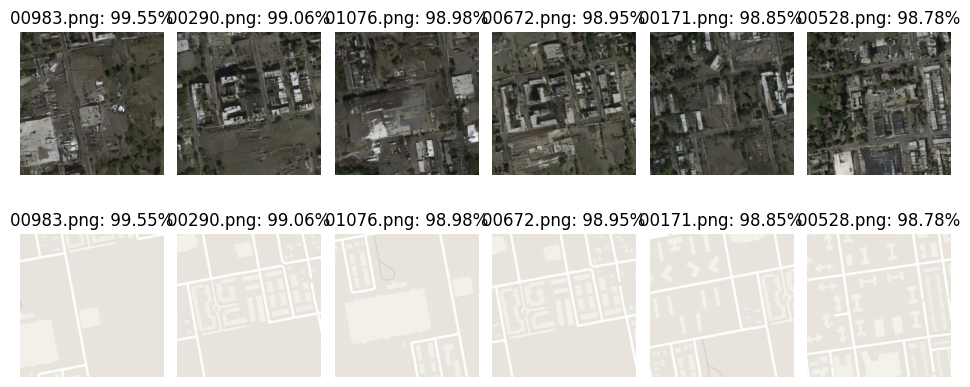

In [9]:
import torch
from PIL import Image
from tqdm import tqdm
import json
from datasets import load_dataset
from torchvision import transforms

### Compute FID per class

def get_Ntop_class_images(input_dir, class_color, N=200, sort=True, exp_path=None):
 
    assert os.path.exists(input_dir)
    img_paths = sorted(glob.glob(os.path.join(input_dir, f"*.png")))
    img_paths2 = [p for p in img_paths if float(os.path.splitext(os.path.basename(p))[0]) <= 1098]
    print(len(img_paths2))
    images = []
    percent_of_class_px_per_img = []
    for p in img_paths2:
        img = np.array(Image.open(p))
        h, w = img.shape[:2]
        val = (np.sum(np.all(img == class_color, axis=2)) / (h*w))*100. 
        percent_of_class_px_per_img.append(val)
        if exp_path is not None:
            im_path = p.replace(os.path.dirname(p), exp_path)
            assert os.path.exists(im_path)
            img = np.array(Image.open(im_path))
            images.append(img)
    if N is None:
        N = len(img_paths2)
    out_images = images
    if sort:
        sorted_idx = np.argsort(percent_of_class_px_per_img)[::-1]
        output_paths = list(np.array(img_paths2)[sorted_idx][:N])
        output_percents = list(np.array(percent_of_class_px_per_img)[sorted_idx][:N])
        if exp_path is not None:
            out_images = list(np.array(images)[sorted_idx][:N])
    else:
        output_paths = img_paths2
        output_percents = percent_of_class_px_per_img
    return output_paths, output_percents, out_images


input_dir = "/home/ubuntu/projects/phase-iv-ai/maps/val_cond_3_for_fid"
exp_id = "2024-08-02_14-35-03_MLBriefs24_5_conditional_CA_encodedmask"
exp_path = f"/media/share/Datasets/diffusers_out/{exp_id}/fid_synthetic/ims"

#input_dir = "/home/ubuntu/projects/phase-iv-ai/maps/train_cond_2"
#exp_path = f"/home/ubuntu/projects/phase-iv-ai/maps/train_ims"

# top vegetation images
#out_paths, out_percents, out_images = get_Ntop_class_images(input_dir , class_color=np.array([0, 255, 0]), exp_path=exp_path)

#top water images
#out_paths, out_percents, out_images = get_Ntop_class_images(input_dir , class_color=np.array([0, 0, 255]), exp_path=exp_path)

#top urban images
out_paths, out_percents, out_images = get_Ntop_class_images(input_dir, class_color=np.array([255, 255, 255]), exp_path=exp_path)

DISPLAY_TOP_N = True
if DISPLAY_TOP_N:
    N = 6
    fig, axes = plt.subplots(2, N, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        if i >= N:
            if exp_path is not None:
                p = out_paths[i-N].replace(os.path.dirname(out_paths[i]), exp_path).replace("/ims", "/cond_ims")
            else:
                #p = output_paths[i-N]
                p = out_paths[i-N].replace("cond_2", "cond")
            percent = out_percents[i-N]
        else:
            if exp_path is not None:
                p = out_paths[i].replace(os.path.dirname(out_paths[i]), exp_path)
            else:
                p = out_paths[i].replace("cond_2", "ims")
            percent = out_percents[i]
        im = np.array(Image.open(p)).astype(np.uint8)
        ax.imshow(im)
        ax.set_title(f"{os.path.basename(p)}: {percent:.2f}%")
        ax.axis('off')  # Hide the axis
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    plt.show()

### Display train and validation distributions

1096
1096
1096
ok


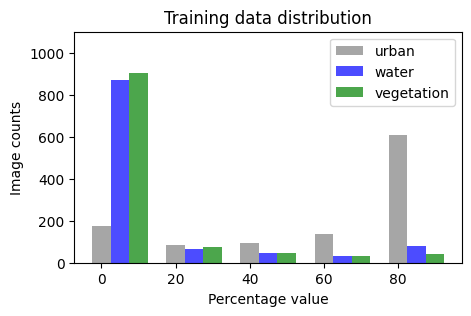

In [55]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_distribution(out_percents_urban, out_percents_water, out_percents_veg, split=None):
    
    X = np.vstack([out_percents_urban, out_percents_water, out_percents_veg]).T

    # Define titles and colors for each column
    titles = ['urban', 'water', 'vegetation']
    colors = ['gray', 'blue', 'green']

    # Number of bins
    num_bins = 5

    # Compute histograms for each column
    hist_data = [np.histogram(X[:, i], bins=num_bins) for i in range(3)]

    # Get the bin edges and heights
    bin_edges = hist_data[0][1]  # All histograms have the same bin edges
    heights = [hist_data[i][0] for i in range(3)]

    # Width of each bin
    width = (bin_edges[1] - bin_edges[0]) / 4

    # Create the figure
    #plt.figure(figsize=(10, 3))
    plt.figure(figsize=(5, 3))

    # Plot each histogram as a bar plot, with offset to place them side by side
    for i in range(3):
        plt.bar(bin_edges[:-1] + i * width, heights[i], width=width, color=colors[i], alpha=0.7, label=titles[i])

    # Add labels and title
    plt.xlabel('Percentage value')
    plt.ylabel('Image counts')
    plt.title(f'{split} data distribution' if split is not None else "Data distribution")
    plt.legend()
    
    plt.ylim(0, 1100)
    plt.yticks(np.arange(0, 1100, 200))

    # Show the plot
    plt.show()

    
input_dir = "/home/ubuntu/projects/phase-iv-ai/maps/train_cond_2"

# top vegetation images
out_paths_veg, out_percents_veg, _ = get_Ntop_class_images(input_dir,
                                                        class_color=np.array([0, 255, 0]), N=None, sort=False)

#top water images
out_paths_water, out_percents_water, _ = get_Ntop_class_images(input_dir,
                                                            class_color=np.array([0, 0, 255]), N=None, sort=False)

#top urban images
out_paths_urban, out_percents_urban, _ = get_Ntop_class_images(input_dir,
                                                            class_color=np.array([255, 255, 255]), N=None, sort=False)

print("ok")
    
plot_class_distribution(out_percents_urban, out_percents_water, out_percents_veg, "Training")

1098
1098
1098
ok


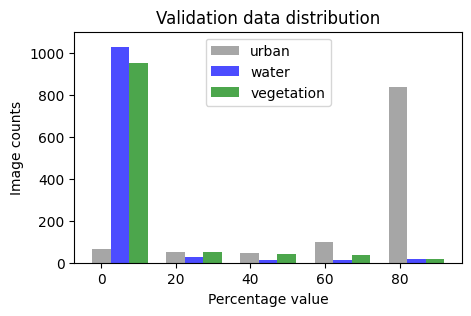

In [56]:
input_dir = "/home/ubuntu/projects/phase-iv-ai/maps/val_cond_2"

# top vegetation images
out_paths_veg, out_percents_veg, _ = get_Ntop_class_images(input_dir,
                                                        class_color=np.array([0, 255, 0]), N=None, sort=False)

#top water images
out_paths_water, out_percents_water, _ = get_Ntop_class_images(input_dir,
                                                            class_color=np.array([0, 0, 255]), N=None, sort=False)

#top urban images
out_paths_urban, out_percents_urban, _ = get_Ntop_class_images(input_dir,
                                                            class_color=np.array([255, 255, 255]), N=None, sort=False)

print("ok")

plot_class_distribution(out_percents_urban, out_percents_water, out_percents_veg, "Validation")

- Compute FID per class and display real vs synthetic samples where that class predominates

1099
1098
ok


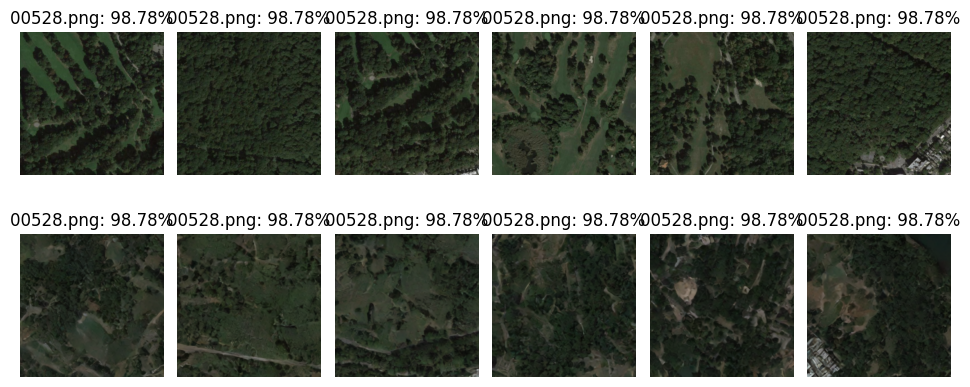

[FID] Computing activations from 200 samples
154.9866928820182


In [42]:
input_dir = "/home/ubuntu/projects/phase-iv-ai/maps/val_cond_3_for_fid"

exp_id = "2024-07-24_22-37-54_MLBriefs24_1_conditional_vanilla_encode_mask"
#exp_id = "2024-07-25_14-27-03_MLBriefs24_2_conditional_vanilla_downsample_mask"
#exp_id = "2024-08-02_14-35-03_MLBriefs24_5_conditional_CA_encodedmask"
#exp_id = "2024-08-01_10-12-17_MLBriefs24_4_conditional_CA_downsampledmask"

exp_path = f"/media/share/Datasets/diffusers_out/{exp_id}/fid_synthetic/ims"

target = "veg"

if target == "urban":
    target_color = np.array([255, 255, 255])
elif target == "water":
    target_color = np.array([0, 0, 255])
elif target == "veg":
    target_color = np.array([0, 255, 0])
out_paths, out_percents, fake_images_ = get_Ntop_class_images(input_dir, class_color=target_color, exp_path=exp_path)

input_dir = "/home/ubuntu/projects/phase-iv-ai/maps/val_cond_2"
exp_path = "/home/ubuntu/projects/phase-iv-ai/maps/val_ims"
out_paths, out_percents, real_images_ = get_Ntop_class_images(input_dir, class_color=target_color, exp_path=exp_path)
fake_images_ = np.stack(fake_images_)
real_images_ = np.stack(real_images_)
print("ok")

DISPLAY_TOP_N = True
if DISPLAY_TOP_N:
    N = 6
    fig, axes = plt.subplots(2, N, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        if i >= N:
            img = fake_images_[i-N]
        else:
            img = real_images_[i]
        ax.imshow(img)
        ax.set_title(f"{os.path.basename(p)}: {percent:.2f}%")
        ax.axis('off')  # Hide the axis
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    plt.show()
    
real_images = torch.from_numpy(real_images_).permute(0, 3, 1, 2).type(torch.float32) / 255.
fake_images = torch.from_numpy(fake_images_).permute(0, 3, 1, 2).type(torch.float32) / 255.

from fid import FID

# requires !pip install scipy==1.9.1
fid = FID(real_images.cuda(), device="cuda")
fid_score = fid.calculate_FID(fake_images.cuda())
print(fid_score)